In [14]:
import pandas as pd

dataset = pd.read_csv("compounds_predicted_pathways.csv")
dataset["Pathways"] = dataset["Pathways"].fillna("NA")
dataset["Pathways"] = dataset["Pathways"].str.split(",").str[0]

In [15]:
dataset["Pathways"]

0              Amino acids and Peptides
1              Amino acids and Peptides
2              Amino acids and Peptides
3              Amino acids and Peptides
4              Amino acids and Peptides
                     ...               
1723    Shikimates and Phenylpropanoids
1724    Shikimates and Phenylpropanoids
1725                          Alkaloids
1726                          Alkaloids
1727    Shikimates and Phenylpropanoids
Name: Pathways, Length: 1728, dtype: object

In [2]:
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def generate_tsne_molecular_similarities(dataset, smiles_field):
    # Create a function to compute molecular fingerprints
    def compute_fingerprint(smiles):
        molecule = Chem.MolFromSmiles(smiles)
        fingerprint = AllChem.GetMorganFingerprintAsBitVect(molecule, 2, nBits=1024)
        return fingerprint

    # Compute molecular fingerprints for each molecule in the combined dataset
    fingerprints = [compute_fingerprint(smiles) for smiles in dataset.loc[:, smiles_field]]

    similarity_matrix = np.zeros((len(fingerprints), len(fingerprints)))
    # Compute molecular similarities using Tanimoto coefficient
    for i in range(len(fingerprints)):
        for j in range(i + 1, len(fingerprints)):
            similarity = DataStructs.TanimotoSimilarity(fingerprints[i], fingerprints[j])
            similarity_matrix[i, j] = similarity
            similarity_matrix[j, i] = similarity

    # Apply t-SNE to reduce the dimensionality
    tsne = TSNE(n_components=2, random_state=42)
    tsne_embeddings = tsne.fit_transform(similarity_matrix)
    # Separate the embeddings based on the original datasets
    dataset["t-sne 1"] = tsne_embeddings[:, 0]
    dataset["t-sne 2"] = tsne_embeddings[:, 1]

    return dataset

dataset = pd.read_csv("compounds_predicted_pathways.csv")
tsne_ = generate_tsne_molecular_similarities(dataset, "SMILES")

In [9]:
tsne_

,ID,SMILES,Pathways,Superclass,Class,t-sne 1,t-sne 2
0,compound_aminotransferase_dataset 1,NCC(=O)O,Amino acids and Peptides,Small peptides,Aminoacids,-38.697678,13.515943
1,compound_aminotransferase_dataset 2,C[C@H](N)C(=O)O,Amino acids and Peptides,Small peptides,Aminoacids,-47.748306,13.672454
2,compound_aminotransferase_dataset 3,CC(C)[C@H](N)C(=O)O,"Amino acids and Peptides, Fatty acids","Fatty Acids and Conjugates, Small peptides","Amino fatty acids, Aminoacids",-47.314949,13.922413
3,compound_aminotransferase_dataset 4,CC(C)C[C@H](N)C(=O)O,"Amino acids and Peptides, Fatty acids","Fatty Acids and Conjugates, Small peptides","Amino fatty acids, Aminoacids",-51.550209,11.199455
4,compound_aminotransferase_dataset 5,CC[C@H](C)[C@H](N)C(=O)O,"Amino acids and Peptides, Fatty acids","Fatty Acids and Conjugates, Small peptides","Amino fatty acids, Aminoacids",-49.123417,12.775739
...,...,...,...,...,...,...,...
1723,heptynoate,C#CCCCCC(=O)Oc1ccc([N+](=O)[O-])cc1,Shikimates and Phenylpropanoids,Fatty Acids and Conjugates,NaN,-28.858986,-12.419436
1724,hexanoate,CCCCCC(=O)Oc1ccc([N+](=O)[O-])cc1,Shikimates and Phenylpropanoids,NaN,NaN,-29.954874,-11.052813
1725,oxidazole,O=C(CCc1nnc(-c2ccccc2)o1)Oc1ccc([N+](=O)[O-])cc1,Alkaloids,NaN,NaN,-28.223740,-13.245775
1726,TMA,CC(C)(C)C(=O)Oc1ccc([N+](=O)[O-])cc1,Alkaloids,NaN,NaN,-28.614882,-13.292257


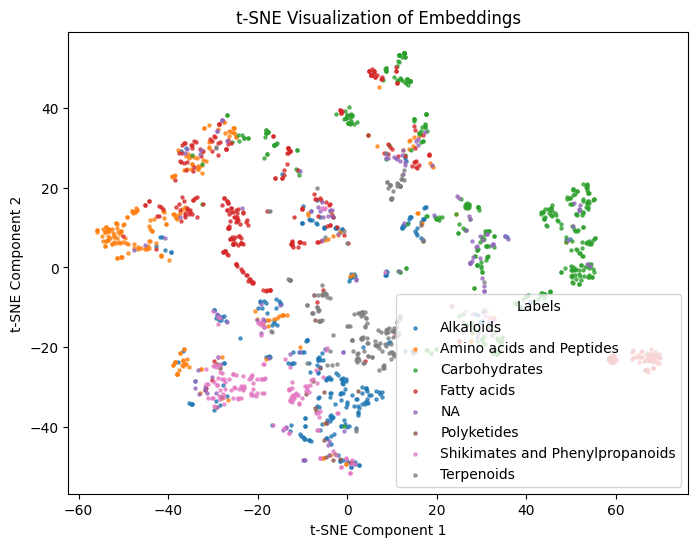

In [16]:
from sklearn.preprocessing import LabelEncoder

# Define unique colors for each class
unique_labels = np.unique(dataset.Pathways)
# Plot with discrete colors
plt.figure(figsize=(8, 6))
for i, label in enumerate(unique_labels):
    idx = np.where(np.array(dataset.Pathways) == str(label))[0]
    plt.scatter(tsne_.loc[idx, "t-sne 1"], tsne_.loc[idx, "t-sne 2"], label=label,  alpha=0.7, s=5)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of Embeddings")

# Add a legend
plt.legend(title="Labels")
plt.show()

In [47]:
import os
from deepmol.loaders import CSVLoader
from deepmol.datasets import SmilesDataset
from deepmol.compound_featurization import ThreeDimensionalMoleculeGenerator

# Processing parameters
timeout = 200
threads = 50
n_conformations = 5
max_iterations = 100
etkdg_version = 3
mode = "MMFF94"

dataset = SmilesDataset(smiles=["C[C@@]12CC[C@@]3(C(=CC[C@H]4[C@]3(CC[C@@H]5[C@@]4(CC[C@@H](C5(C)C)O)C)C)[C@@H]1CC(CC2)(C)C)C"])
            
# Generate 3D conformers
generator = ThreeDimensionalMoleculeGenerator(
    timeout_per_molecule=timeout, threads=threads,
    n_conformations=n_conformations, max_iterations=max_iterations
)
generator.generate(dataset, etkdg_version=etkdg_version, mode=mode)

Generating 3D structure: 100%|██████████| 1/1 [00:02<00:00,  2.85s/it]


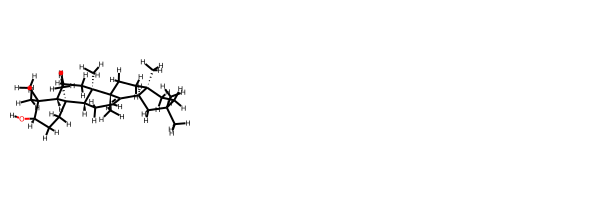

In [35]:
from rdkit.Chem import Draw
Draw.MolsToGridImage(dataset.mols)

In [48]:
import py3Dmol

# Align conformers to the first conformer
rmslist = []
molecule = dataset.mols[0]
AllChem.AlignMolConformers(molecule, RMSlist=rmslist, confIds=[i for i in range(molecule.GetNumConformers())])
# Remove hydrogens from the molecule
molecule = Chem.RemoveHs(molecule)

# Prepare the 3D view
view = py3Dmol.view(width=800, height=400)

# Add each conformer to the view
for confId in range(molecule.GetNumConformers()):
    mb = Chem.MolToMolBlock(molecule, confId=confId)
    view.addModel(mb, 'sdf')

# Set style and other visualization options
view.setStyle({'stick': {}})
view.zoomTo()
# Show the 3D view
view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

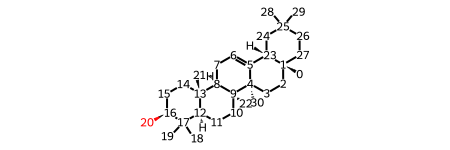

In [46]:
dataset = SmilesDataset(smiles=["C[C@@]12CC[C@@]3(C(=CC[C@H]4[C@]3(CC[C@@H]5[C@@]4(CC[C@@H](C5(C)C)O)C)C)[C@@H]1CC(CC2)(C)C)C"])
# Number the atoms
# Step 2: Add atom numbers
for atom in dataset.mols[0].GetAtoms():
    atom.SetProp('atomLabel', str(atom.GetIdx()))

dataset.mols[0]